Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6341 - loss: 0.6389 - val_accuracy: 0.6870 - val_loss: 0.6006
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6897 - loss: 0.5681 - val_accuracy: 0.7099 - val_loss: 0.5525
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7586 - loss: 0.5103 - val_accuracy: 0.7557 - val_loss: 0.5093
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8103 - loss: 0.4589 - val_accuracy: 0.7939 - val_loss: 0.4734
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8429 - loss: 0.4195 - val_accuracy: 0.8321 - val_loss: 0.4466
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3874 - val_accuracy: 0.8168 - val_loss: 0.4276
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8563 - loss: 0.3666 - val_accuracy: 0.8321 - val_loss: 0.4128
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8640 - loss: 0.3490 - val_accuracy: 0.8397 - val_loss: 0.4033
Ep

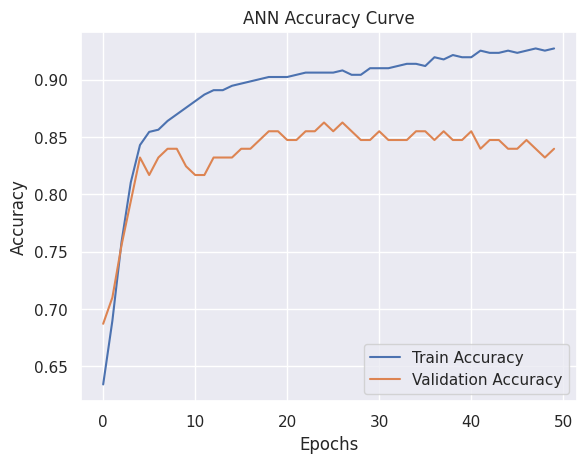

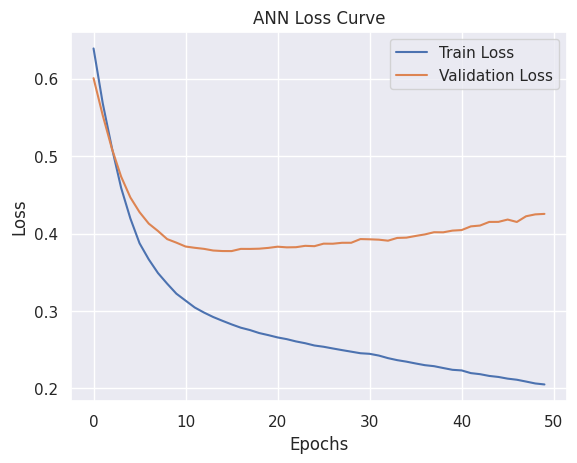

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


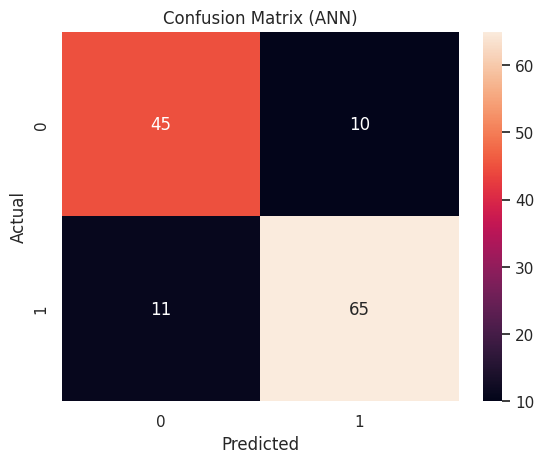

Accuracy: 0.8396946564885496

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81        55
           1       0.87      0.86      0.86        76

    accuracy                           0.84       131
   macro avg       0.84      0.84      0.84       131
weighted avg       0.84      0.84      0.84       131



In [2]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

sns.set()

# ================================
# LOAD DATASET
# ================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns = [f"A{i}" for i in range(1, 17)]
df = pd.read_csv(url, header=None, names=columns)

# ================================
# PREPROCESSING
# ================================

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Split features and target
X = df.drop(columns=['A16'])
y = df['A16']

# Encode categorical features
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# Encode target
y = LabelEncoder().fit_transform(y)

# ================================
# SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ================================
# 🧠 BUILD ANN MODEL
# ================================
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================================
# TRAIN MODEL
# ================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

# ================================
# 📈 TRAINING CURVES
# ================================

# Accuracy Curve
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Curve
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ================================
# 🔍 PREDICTIONS
# ================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# ================================
# 📊 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (ANN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 📋 REPORT
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))